### Оценка долгосрочного эффекта вирусного флешмоба методом CausalImpact

**Цель анализа:** Оценить чистый (причинно-следственный) эффект от проведенного пользователями флешмоба на ряд метрик, исключив влияние естественных колебаний других метрик.

**Специфика метрик:**
* `DAU` и `Views` выступают предикторами общего трафика платформы.
* `New_Posts` отражает генерацию контента.
* `Unique_Viewed_Posts` выбрана в качестве целевой переменной ($Y$). Она учитывает структуру социальной сети: один и тот же пост может просматриваться в разные дни разными пользователями, поэтому всплеск этой метрики покажет реальное расширение сетевого взаимодействия.

**Методология:** 
Используется базовая байесовская модель структурных временных рядов (Structural Time-Series) в конфигурации *Local Level* (без включения компонентов линейного тренда и сезонности). Модель строит контрфактуал (прогноз того, как вела бы себя целевая метрика без флешмоба) на основе поведения ковариат в `pre_period`, а затем сравнивает его с фактическими данными в `post_period`.


In [ ]:
#общие для обработки данных
import pandas as pd
import pandahouse as ph

#общие штуки для рисования
import seaborn as sns
import matplotlib.pyplot as plt

import tensorflow as tf
import tensorflow_probability as tfp

from causalimpact import CausalImpact
from tqdm import tqdm

In [ ]:
# Параметры подключения
connection = {
    'host': 'http://clickhouse.lab.karpov.courses:8123',
    'password': 'dpo_python_2020',
    'user': 'student',
    'database': 'simulator_20260420'
}

In [2]:
# Запрос для DAU, CTR, число просмотров и уникальных постов

query = '''
SELECT 
    toDate(time) as date,
    COUNT(DISTINCT user_id) as DAU,
    countIf(action = 'like')/countIf(action = 'view') as CTR,
    countIf(action = 'view') as count_of_views,
    COUNT(DISTINCT post_id) AS unique_posts
FROM 
    {db}.feed_actions
GROUP BY date
ORDER BY date
'''

In [4]:
# Запрос для числа новых постов по дням

query_2 = '''
SELECT first_date as date,
    COUNT(post_id) as new_posts
FROM (    
SELECT 
    post_id,
    MIN(toDate(time)) AS first_date
FROM 
    {db}.feed_actions
GROUP BY post_id     
ORDER BY post_id     
) t1
GROUP BY date
'''

In [5]:
# Загрузка данных в датафрейм

activity = ph.read_clickhouse(query=query, connection=connection)
activity.head()

,date,DAU,CTR,count_of_views,unique_posts
0,2026-03-07,878,0.205182,7603,89
1,2026-03-08,2238,0.204174,62770,178
2,2026-03-09,3105,0.198605,105526,191
3,2026-03-10,3721,0.200007,118996,211
4,2026-03-11,4617,0.197783,174454,214


In [6]:
activity_new_posts = ph.read_clickhouse(query=query_2, connection=connection)

In [7]:
activity = activity.merge(activity_new_posts, on = 'date')
activity.head()

,date,DAU,CTR,count_of_views,unique_posts,new_posts
0,2026-03-07,878,0.205182,7603,89,89
1,2026-03-08,2238,0.204174,62770,178,97
2,2026-03-09,3105,0.198605,105526,191,61
3,2026-03-10,3721,0.200007,118996,211,87
4,2026-03-11,4617,0.197783,174454,214,70


In [8]:
# Преобразование индекса в нужный формат
activity['date'] = pd.to_datetime(activity['date'])
activity.set_index('date', inplace=True)

In [12]:
# Настройка пред- и пост-периодов
pre_period = ['2026-04-17', '2026-04-23']
post_period = ['2026-04-24', '2026-05-11']

In [13]:
# Задаем метрики
metrics = ['DAU', 'CTR', 'count_of_views', 'unique_posts', 'new_posts']

  0%|          | 0/5 [00:00<?, ?it/s]

Instructions for updating:
back_prop=False is deprecated. Consider using tf.stop_gradient instead.
Instead of:
results = tf.while_loop(c, b, vars, back_prop=False)
Use:
results = tf.nest.map_structure(tf.stop_gradient, tf.while_loop(c, b, vars))


2026-05-12 16:21:01.174749: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'shape' with dtype int32 and shape [1]
	 [[{{node shape}}]]
2026-05-12 16:21:01.174914: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'shape' with dtype int32 and shape [1]
	 [[{{node shape}}]]
2026-05-12 16:21:01.183369: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'shape' with dtype int32 and shape [1]
	 [[{{node shape}}]]
2026-05-12 16:21:01.183486: I tens

Instructions for updating:
Please use `StructuralTimeSeries.joint_distribution(observed_time_series).log_prob`


2026-05-12 16:21:01.900997: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INTERNAL: No function library is provided.
	 [[{{node powerInverseGamma_CONSTRUCTED_AT_joint_log_prob/sample/InverseGamma/sample/PartitionedCall}}]]
2026-05-12 16:21:01.918967: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INTERNAL: No function library is provided.
	 [[{{node powerInverseGamma_1_CONSTRUCTED_AT_joint_log_prob/sample/InverseGamma/sample/PartitionedCall}}]]
2026-05-12 16:21:01.946602: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INTERNAL: No function library is provided.
	 [[{{node monte_carlo_variational_loss/expectation/powerInv

Instructions for updating:
`Predictive distributions returned by`tfp.sts.one_step_predictive` will soon compute per-timestep probabilities (treating timesteps as part of the batch shape) instead of a single probability for an entire series (the current approach, in which timesteps are treated as event shape). Please update your code to pass `timesteps_are_event_shape=False` (this will soon be the default) and to explicitly sum over the per-timestep log probabilities if this is required.


2026-05-12 16:21:10.710681: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'AdditiveStateSpaceModel/sample/AdditiveStateSpaceModel/sample_n_joint/scan/while/strided_slice/AdditiveStateSpaceModel/sample/AdditiveStateSpaceModel/sample_n_joint/concat_1' with dtype int32 and shape [2]
	 [[{{node AdditiveStateSpaceModel/sample/AdditiveStateSpaceModel/sample_n_joint/scan/while/strided_slice/AdditiveStateSpaceModel/sample/AdditiveStateSpaceModel/sample_n_joint/concat_1}}]]
2026-05-12 16:21:10.765735: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'AdditiveStateSpaceModel/sample/AdditiveStateSpaceModel/sample_n_joint/scan/whil

Анализ DAU


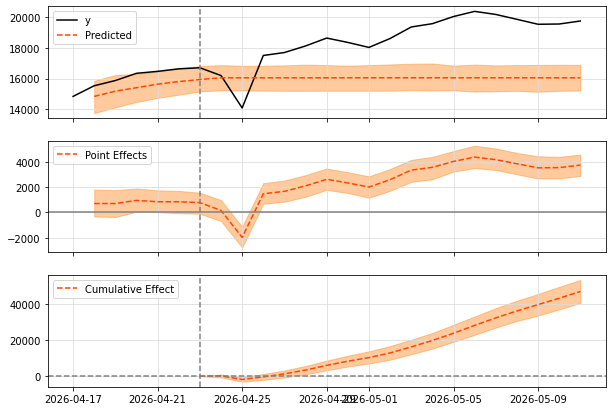

 20%|██        | 1/5 [00:11<00:46, 11.58s/it]

Posterior Inference {Causal Impact}
                          Average            Cumulative
Actual                    18649.61           335693.0
Prediction (s.d.)         16045.84 (179.5)   288825.06 (3231.05)
95% CI                    [15678.38, 16382.02][282210.86, 294876.36]

Absolute effect (s.d.)    2603.77 (179.5)    46867.94 (3231.05)
95% CI                    [2267.59, 2971.23] [40816.64, 53482.14]

Relative effect (s.d.)    16.23% (1.12%)     16.23% (1.12%)
95% CI                    [14.13%, 18.52%]   [14.13%, 18.52%]

Posterior tail-area probability p: 0.0
Posterior prob. of a causal effect: 100.0%

For more details run the command: print(impact.summary('report'))


2026-05-12 16:21:12.646675: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INTERNAL: No function library is provided.
	 [[{{node powerInverseGamma/sample/InverseGamma/sample/PartitionedCall}}]]
2026-05-12 16:21:12.662703: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INTERNAL: No function library is provided.
	 [[{{node powerInverseGamma/sample_1/InverseGamma/sample/PartitionedCall}}]]
2026-05-12 16:21:13.065773: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INTERNAL: No function library is provided.
	 [[{{node powerInverseGamma_CONSTRUCTED_AT_joint_log_prob/sample/InverseGamma/sample/PartitionedCall}}]]
2026-05-12 16:

Анализ CTR


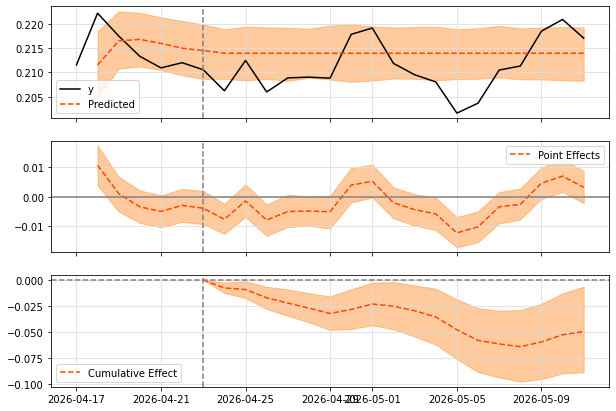

 40%|████      | 2/5 [00:22<00:33, 11.25s/it]

Posterior Inference {Causal Impact}
                          Average            Cumulative
Actual                    0.21               3.8
Prediction (s.d.)         0.21 (0.0)         3.85 (0.02)
95% CI                    [0.21, 0.22]       [3.82, 3.89]

Absolute effect (s.d.)    -0.0 (0.0)         -0.05 (0.02)
95% CI                    [-0.01, -0.0]      [-0.09, -0.01]

Relative effect (s.d.)    -1.29% (0.51%)     -1.29% (0.51%)
95% CI                    [-2.35%, -0.36%]   [-2.35%, -0.36%]

Posterior tail-area probability p: 0.0
Posterior prob. of a causal effect: 99.6%

For more details run the command: print(impact.summary('report'))


2026-05-12 16:21:23.661972: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INTERNAL: No function library is provided.
	 [[{{node powerInverseGamma/sample/InverseGamma/sample/PartitionedCall}}]]
2026-05-12 16:21:23.678846: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INTERNAL: No function library is provided.
	 [[{{node powerInverseGamma/sample_1/InverseGamma/sample/PartitionedCall}}]]
2026-05-12 16:21:24.066865: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INTERNAL: No function library is provided.
	 [[{{node powerInverseGamma_CONSTRUCTED_AT_joint_log_prob/sample/InverseGamma/sample/PartitionedCall}}]]
2026-05-12 16:

2026-05-12 16:21:33.377910: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'AdditiveStateSpaceModel/sample/AdditiveStateSpaceModel/sample_n_joint/scan/while/strided_slice/AdditiveStateSpaceModel/sample/AdditiveStateSpaceModel/sample_n_joint/concat_1' with dtype int32 and shape [2]
	 [[{{node AdditiveStateSpaceModel/sample/AdditiveStateSpaceModel/sample_n_joint/scan/while/strided_slice/AdditiveStateSpaceModel/sample/AdditiveStateSpaceModel/sample_n_joint/concat_1}}]]
2026-05-12 16:21:33.437813: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'AdditiveStateSpaceModel/sample/AdditiveStateSpaceModel/sample_n_joint/scan/whil

Анализ count_of_views


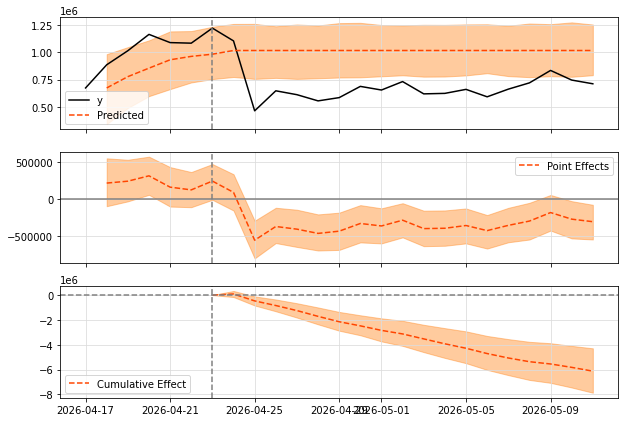

 60%|██████    | 3/5 [00:34<00:22, 11.49s/it]

Posterior Inference {Causal Impact}
                          Average            Cumulative
Actual                    677102.31          12187842.0
Prediction (s.d.)         1017727.44 (50153.8)18319094.0 (902768.61)
95% CI                    [923597.11, 1120196.45][16624748.1, 20163536.75]

Absolute effect (s.d.)    -340625.12 (50153.8)-6131252.0 (902768.61)
95% CI                    [-443094.13, -246494.8][-7975694.75, -4436906.1]

Relative effect (s.d.)    -33.47% (4.93%)    -33.47% (4.93%)
95% CI                    [-43.54%, -24.22%] [-43.54%, -24.22%]

Posterior tail-area probability p: 0.0
Posterior prob. of a causal effect: 100.0%

For more details run the command: print(impact.summary('report'))


2026-05-12 16:21:35.442284: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INTERNAL: No function library is provided.
	 [[{{node powerInverseGamma/sample/InverseGamma/sample/PartitionedCall}}]]
2026-05-12 16:21:35.459809: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INTERNAL: No function library is provided.
	 [[{{node powerInverseGamma/sample_1/InverseGamma/sample/PartitionedCall}}]]
2026-05-12 16:21:35.855525: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INTERNAL: No function library is provided.
	 [[{{node powerInverseGamma_CONSTRUCTED_AT_joint_log_prob/sample/InverseGamma/sample/PartitionedCall}}]]
2026-05-12 16:

Анализ unique_posts


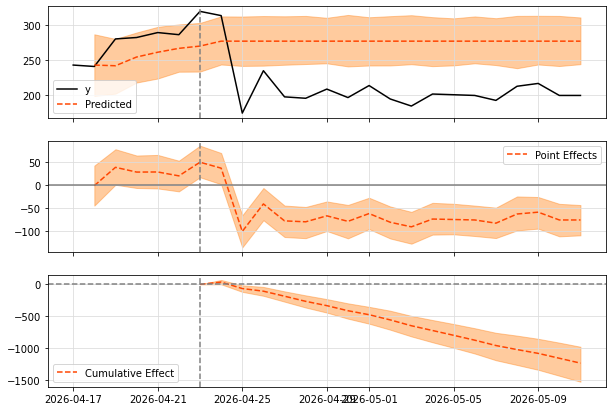

 80%|████████  | 4/5 [00:45<00:11, 11.43s/it]

Posterior Inference {Causal Impact}
                          Average            Cumulative
Actual                    207.94             3743.0
Prediction (s.d.)         276.83 (7.24)      4983.0 (130.28)
95% CI                    [261.99, 290.36]   [4715.85, 5226.52]

Absolute effect (s.d.)    -68.89 (7.24)      -1240.0 (130.28)
95% CI                    [-82.42, -54.05]   [-1483.52, -972.85]

Relative effect (s.d.)    -24.88% (2.61%)    -24.88% (2.61%)
95% CI                    [-29.77%, -19.52%] [-29.77%, -19.52%]

Posterior tail-area probability p: 0.0
Posterior prob. of a causal effect: 100.0%

For more details run the command: print(impact.summary('report'))


2026-05-12 16:21:46.790949: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INTERNAL: No function library is provided.
	 [[{{node powerInverseGamma/sample/InverseGamma/sample/PartitionedCall}}]]
2026-05-12 16:21:46.809785: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INTERNAL: No function library is provided.
	 [[{{node powerInverseGamma/sample_1/InverseGamma/sample/PartitionedCall}}]]
2026-05-12 16:21:47.212616: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INTERNAL: No function library is provided.
	 [[{{node powerInverseGamma_CONSTRUCTED_AT_joint_log_prob/sample/InverseGamma/sample/PartitionedCall}}]]
2026-05-12 16:

2026-05-12 16:21:55.607443: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'AdditiveStateSpaceModel/sample/AdditiveStateSpaceModel/sample_n_joint/scan/while/strided_slice/AdditiveStateSpaceModel/sample/AdditiveStateSpaceModel/sample_n_joint/concat_1' with dtype int32 and shape [2]
	 [[{{node AdditiveStateSpaceModel/sample/AdditiveStateSpaceModel/sample_n_joint/scan/while/strided_slice/AdditiveStateSpaceModel/sample/AdditiveStateSpaceModel/sample_n_joint/concat_1}}]]
2026-05-12 16:21:55.662559: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'AdditiveStateSpaceModel/sample/AdditiveStateSpaceModel/sample_n_joint/scan/whil

Анализ new_posts


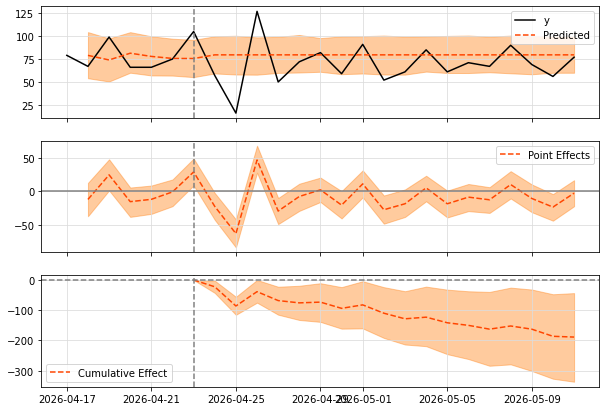

100%|██████████| 5/5 [00:56<00:00, 11.31s/it]

Posterior Inference {Causal Impact}
                          Average            Cumulative
Actual                    69.06              1243.0
Prediction (s.d.)         79.55 (4.32)       1431.96 (77.8)
95% CI                    [71.01, 87.95]     [1278.12, 1583.09]

Absolute effect (s.d.)    -10.5 (4.32)       -188.96 (77.8)
95% CI                    [-18.89, -1.95]    [-340.09, -35.12]

Relative effect (s.d.)    -13.2% (5.43%)     -13.2% (5.43%)
95% CI                    [-23.75%, -2.45%]  [-23.75%, -2.45%]

Posterior tail-area probability p: 0.01
Posterior prob. of a causal effect: 99.4%

For more details run the command: print(impact.summary('report'))


In [14]:
# Применяем CausalImpact

for i in tqdm(metrics):
    impact = CausalImpact(data = activity[i], 
                          pre_period = pre_period, 
                          post_period = post_period)
    print(f'Анализ {i}: сравнение периода флешмоба с долгосрочной перспективой')
    impact.plot()
    print(impact.summary())

In [15]:
# Настройка пред- и пост-периодов до флешмоба и долгосрочной перспективы
pre_period_before = ['2026-03-07', '2026-04-16']
post_period_after = ['2026-04-24', '2026-05-11']

  0%|          | 0/5 [00:00<?, ?it/s]2026-05-12 16:26:25.959351: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INTERNAL: No function library is provided.
	 [[{{node powerInverseGamma/sample/InverseGamma/sample/PartitionedCall}}]]
2026-05-12 16:26:25.977685: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INTERNAL: No function library is provided.
	 [[{{node powerInverseGamma/sample_1/InverseGamma/sample/PartitionedCall}}]]
2026-05-12 16:26:26.377195: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INTERNAL: No function library is provided.
	 [[{{node powerInverseGamma_CONSTRUCTED_AT_joint_log_prob/sample/InverseGamma/samp

2026-05-12 16:26:40.172446: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'AdditiveStateSpaceModel/sample/AdditiveStateSpaceModel/sample_n_joint/scan/while/strided_slice/AdditiveStateSpaceModel/sample/AdditiveStateSpaceModel/sample_n_joint/concat_1' with dtype int32 and shape [2]
	 [[{{node AdditiveStateSpaceModel/sample/AdditiveStateSpaceModel/sample_n_joint/scan/while/strided_slice/AdditiveStateSpaceModel/sample/AdditiveStateSpaceModel/sample_n_joint/concat_1}}]]
2026-05-12 16:26:40.240132: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'AdditiveStateSpaceModel/sample/AdditiveStateSpaceModel/sample_n_joint/scan/whil

Анализ DAU: сравнение периода до флешмоба с долгосрочной перспективой


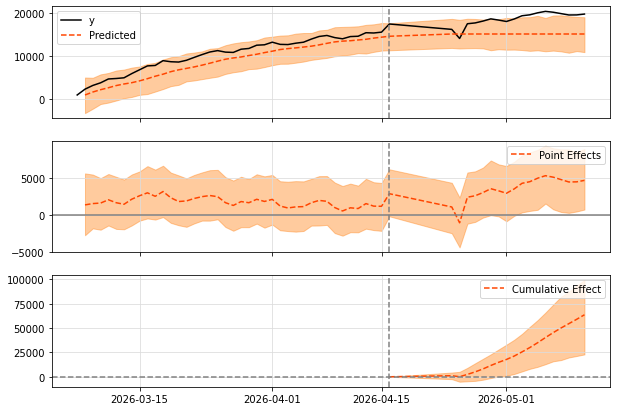

 20%|██        | 1/5 [00:16<01:05, 16.26s/it]

Posterior Inference {Causal Impact}
                          Average            Cumulative
Actual                    18649.61           335693.0
Prediction (s.d.)         15115.85 (1144.39) 272085.22 (20599.09)
95% CI                    [12938.9, 17424.84][232900.15, 313647.12]

Absolute effect (s.d.)    3533.77 (1144.39)  63607.78 (20599.09)
95% CI                    [1224.77, 5710.71] [22045.88, 102792.85]

Relative effect (s.d.)    23.38% (7.57%)     23.38% (7.57%)
95% CI                    [8.1%, 37.78%]     [8.1%, 37.78%]

Posterior tail-area probability p: 0.0
Posterior prob. of a causal effect: 100.0%

For more details run the command: print(impact.summary('report'))


2026-05-12 16:26:42.218547: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INTERNAL: No function library is provided.
	 [[{{node powerInverseGamma/sample/InverseGamma/sample/PartitionedCall}}]]
2026-05-12 16:26:42.237519: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INTERNAL: No function library is provided.
	 [[{{node powerInverseGamma/sample_1/InverseGamma/sample/PartitionedCall}}]]
2026-05-12 16:26:42.633389: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INTERNAL: No function library is provided.
	 [[{{node powerInverseGamma_CONSTRUCTED_AT_joint_log_prob/sample/InverseGamma/sample/PartitionedCall}}]]
2026-05-12 16:

Анализ CTR: сравнение периода до флешмоба с долгосрочной перспективой


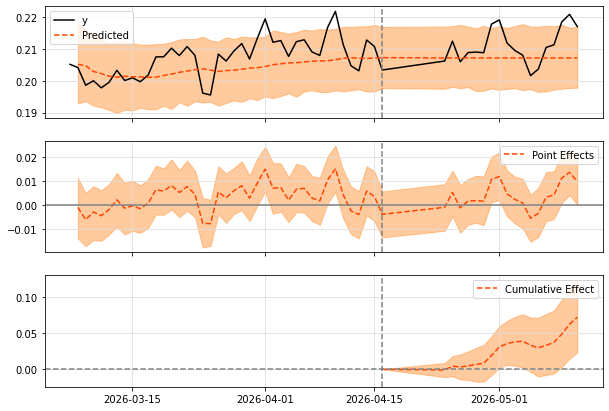

 40%|████      | 2/5 [00:32<00:49, 16.47s/it]

Posterior Inference {Causal Impact}
                          Average            Cumulative
Actual                    0.21               3.8
Prediction (s.d.)         0.21 (0.0)         3.73 (0.03)
95% CI                    [0.2, 0.21]        [3.68, 3.78]

Absolute effect (s.d.)    0.0 (0.0)          0.07 (0.03)
95% CI                    [0.0, 0.01]        [0.02, 0.12]

Relative effect (s.d.)    1.93% (0.69%)      1.93% (0.69%)
95% CI                    [0.55%, 3.26%]     [0.55%, 3.26%]

Posterior tail-area probability p: 0.0
Posterior prob. of a causal effect: 99.7%

For more details run the command: print(impact.summary('report'))


2026-05-12 16:26:58.836829: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INTERNAL: No function library is provided.
	 [[{{node powerInverseGamma/sample/InverseGamma/sample/PartitionedCall}}]]
2026-05-12 16:26:58.856078: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INTERNAL: No function library is provided.
	 [[{{node powerInverseGamma/sample_1/InverseGamma/sample/PartitionedCall}}]]
2026-05-12 16:26:59.265177: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INTERNAL: No function library is provided.
	 [[{{node powerInverseGamma_CONSTRUCTED_AT_joint_log_prob/sample/InverseGamma/sample/PartitionedCall}}]]
2026-05-12 16:

Анализ count_of_views: сравнение периода до флешмоба с долгосрочной перспективой


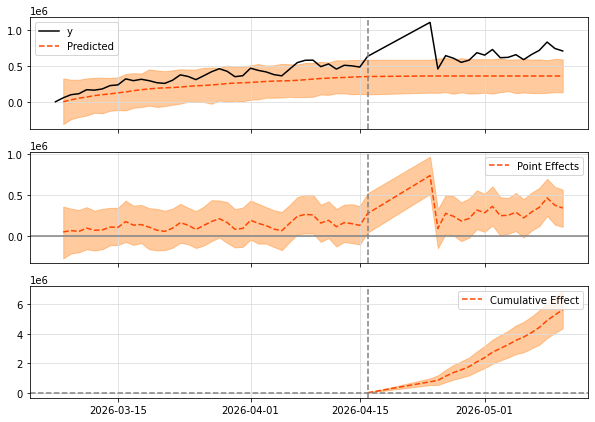

 60%|██████    | 3/5 [00:49<00:32, 16.49s/it]

Posterior Inference {Causal Impact}
                          Average            Cumulative
Actual                    677102.31          12187842.0
Prediction (s.d.)         364284.5 (32391.3) 6557121.0 (583043.34)
95% CI                    [303254.59, 430226.18][5458582.62, 7744071.0]

Absolute effect (s.d.)    312817.81 (32391.3)5630721.0 (583043.34)
95% CI                    [246876.13, 373847.72][4443771.0, 6729259.38]

Relative effect (s.d.)    85.87% (8.89%)     85.87% (8.89%)
95% CI                    [67.77%, 102.63%]  [67.77%, 102.63%]

Posterior tail-area probability p: 0.0
Posterior prob. of a causal effect: 100.0%

For more details run the command: print(impact.summary('report'))


2026-05-12 16:27:15.354294: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INTERNAL: No function library is provided.
	 [[{{node powerInverseGamma/sample/InverseGamma/sample/PartitionedCall}}]]
2026-05-12 16:27:15.373446: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INTERNAL: No function library is provided.
	 [[{{node powerInverseGamma/sample_1/InverseGamma/sample/PartitionedCall}}]]
2026-05-12 16:27:15.789490: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INTERNAL: No function library is provided.
	 [[{{node powerInverseGamma_CONSTRUCTED_AT_joint_log_prob/sample/InverseGamma/sample/PartitionedCall}}]]
2026-05-12 16:

Анализ unique_posts: сравнение периода до флешмоба с долгосрочной перспективой


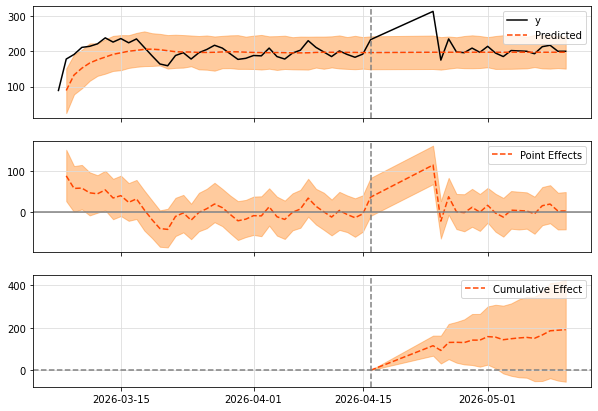

 80%|████████  | 4/5 [01:05<00:16, 16.41s/it]

Posterior Inference {Causal Impact}
                          Average            Cumulative
Actual                    207.94             3743.0
Prediction (s.d.)         197.32 (6.69)      3551.77 (120.44)
95% CI                    [184.22, 210.44]   [3315.88, 3787.99]

Absolute effect (s.d.)    10.62 (6.69)       191.23 (120.44)
95% CI                    [-2.5, 23.73]      [-44.99, 427.12]

Relative effect (s.d.)    5.38% (3.39%)      5.38% (3.39%)
95% CI                    [-1.27%, 12.03%]   [-1.27%, 12.03%]

Posterior tail-area probability p: 0.06
Posterior prob. of a causal effect: 94.21%

For more details run the command: print(impact.summary('report'))


2026-05-12 16:27:31.634133: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INTERNAL: No function library is provided.
	 [[{{node powerInverseGamma/sample/InverseGamma/sample/PartitionedCall}}]]
2026-05-12 16:27:31.653318: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INTERNAL: No function library is provided.
	 [[{{node powerInverseGamma/sample_1/InverseGamma/sample/PartitionedCall}}]]
2026-05-12 16:27:32.066507: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INTERNAL: No function library is provided.
	 [[{{node powerInverseGamma_CONSTRUCTED_AT_joint_log_prob/sample/InverseGamma/sample/PartitionedCall}}]]
2026-05-12 16:

Анализ new_posts: сравнение периода до флешмоба с долгосрочной перспективой


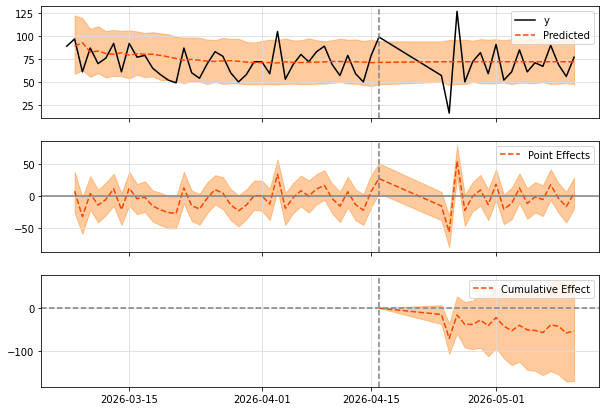

100%|██████████| 5/5 [01:22<00:00, 16.56s/it]

Posterior Inference {Causal Impact}
                          Average            Cumulative
Actual                    69.06              1243.0
Prediction (s.d.)         72.02 (3.48)       1296.44 (62.6)
95% CI                    [65.44, 79.08]     [1178.01, 1423.4]

Absolute effect (s.d.)    -2.97 (3.48)       -53.44 (62.6)
95% CI                    [-10.02, 3.61]     [-180.4, 64.99]

Relative effect (s.d.)    -4.12% (4.83%)     -4.12% (4.83%)
95% CI                    [-13.92%, 5.01%]   [-13.92%, 5.01%]

Posterior tail-area probability p: 0.18
Posterior prob. of a causal effect: 81.82%

For more details run the command: print(impact.summary('report'))


In [16]:
# Применяем CausalImpact

for i in tqdm(metrics):
    impact = CausalImpact(data = activity[i], 
                          pre_period = pre_period_before, 
                          post_period = post_period_after)
    print(f'Анализ {i}: сравнение периода до флешмоба с долгосрочной перспективой')
    impact.plot()
    print(impact.summary())

Вывод:  
- DAU просмотров значимо выросло. Средняя величина относительного эффекта - примерно 23.38%, однако неизвестно, связано ли это с эффеетом флешмоба или с общей тенденцией роста DAU во времени.
- CTR значимо, но незначительно вырос. Средняя величина относительного эффекта - примерно 1.93%.  
- Число просмотров значимо выросло. Средняя величина относительного эффекта - примерно 85.87%.      
- Число новых постов значимо не изменилось.  
- Число уникальных просматриваемых постов значимо не изменилось.  